# Проект по анализу данных

# КТ 1

Тема исследования:
«Анализ факторов, влияющих на уровень цифровой грамотности»

Описание и цели:
Проект направлен на изучение взаимосвязи различных факторов (демографических, социально-экономических и образовательных) 
и уровня цифровой грамотности населения. В результате работы можно будет определить ключевые факторы, 
влияющие на цифровую грамотность, а также выявить возможные пути её повышения, что может быть полезным 
для образовательных программ и стратегий по развитию цифровых навыков.

Датасет:
https://www.kaggle.com/datasets/ziya07/digital-literacy-education-dataset

# КТ 2

In [6]:
import pandas as pd
import numpy as np
df = pd.read_csv('digital_literacy_dataset .csv')
df.head()

,User_ID,Age,Gender,Education_Level,Employment_Status,Household_Income,Location_Type,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,...,Modules_Completed,Average_Time_Per_Module,Quiz_Performance,Session_Count,Engagement_Level,Adaptability_Score,Feedback_Rating,Skill_Application,Employment_Impact,Overall_Literacy_Score
0,U0001,43,Male,Primary,Student,Medium,Semi-Rural,25,1,33,...,7,15.85,92,12,Low,77,4,51,Yes,58.2
1,U0002,60,Female,High School,Farmer,Low,Rural,22,14,35,...,9,22.24,88,24,Low,76,4,98,Yes,55.3
2,U0003,47,Female,Primary,Farmer,Low,Semi-Rural,14,31,14,...,13,12.15,67,17,Low,67,5,75,Yes,52.3
3,U0004,34,Female,Secondary,Farmer,Low,Rural,6,32,17,...,8,25.59,69,28,Medium,59,1,61,Yes,55.5
4,U0005,50,Male,High School,Other,Medium,Rural,14,41,19,...,8,16.65,76,10,Medium,90,4,82,No,59.3


## Разведочный анализ данных

In [7]:
df.shape

(1000, 23)

В датасете 1000 строк и 23 столбца

Описание признаков в датасете:

Числовые

Непрерывные:
- Average_Time_Per_Module
- Overall_Literacy_Score 

Дискретные:
- Age
- Basic_Computer_Knowledge_Score
- Internet_Usage_Score
- Mobile_Literacy_Score
- Post_Training_Basic_Computer_Knowledge_Score
- Post_Training_Internet_Usage_Score
- Post_Training_Mobile_Literacy_Score
- Modules_Completed
- Quiz_Performance
- Session_Count
- Adaptability_Score
- Feedback_Rating
- Skill_Application

  

Категориальные

Номинальные (не можем упорядочить):
- User_ID
- Gender('Male', 'Female')  - бинарный признак
- Employment_Status
- Location_Type ('Semi-Rural', 'Rural')
- Employment_Impact ('Yes', 'No')  - бинарный признак

Порядковые (можем упорядочить):
- Education_Level ('Primary', 'Secondary', 'High School')  
- Household_Income  ('Low', 'Medium', 'High')  
- Engagement_Level ('Low', 'Medium', 'High')тельный анализ.

In [8]:
df.isna().sum()

User_ID                                           0
Age                                               0
Gender                                            0
Education_Level                                 212
Employment_Status                                 0
Household_Income                                  0
Location_Type                                     0
Basic_Computer_Knowledge_Score                    0
Internet_Usage_Score                              0
Mobile_Literacy_Score                             0
Post_Training_Basic_Computer_Knowledge_Score      0
Post_Training_Internet_Usage_Score                0
Post_Training_Mobile_Literacy_Score               0
Modules_Completed                                 0
Average_Time_Per_Module                           0
Quiz_Performance                                  0
Session_Count                                     0
Engagement_Level                                  0
Adaptability_Score                                0
Feedback_Rat

В датасете есть пропуски только в данных по уровню образования (Education_Level)
Так как в данной колонке категориальные данные, то пропуски заменяем на моду

In [9]:
df['Education_Level'].mode()[0]

'Primary'

In [10]:
df['Education_Level_fillna'] = df['Education_Level'].fillna(df['Education_Level'].mode()[0]) 
df[df['Education_Level'].isna()]

,User_ID,Age,Gender,Education_Level,Employment_Status,Household_Income,Location_Type,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,...,Average_Time_Per_Module,Quiz_Performance,Session_Count,Engagement_Level,Adaptability_Score,Feedback_Rating,Skill_Application,Employment_Impact,Overall_Literacy_Score,Education_Level_fillna
10,U0011,28,Male,NaN,Other,Low,Rural,40,19,50,...,20.05,89,16,Low,100,2,55,No,68.2,Primary
13,U0014,52,Male,NaN,Unemployed,Medium,Rural,47,29,24,...,16.96,61,25,Medium,67,5,64,No,64.9,Primary
20,U0021,60,Male,NaN,Self-Employed,Low,Rural,22,32,35,...,17.09,75,19,Medium,98,5,56,Yes,65.6,Primary
32,U0033,35,Male,NaN,Self-Employed,Low,Rural,12,20,41,...,17.61,69,27,Low,66,5,74,Yes,52.0,Primary
34,U0035,55,Female,NaN,Self-Employed,Medium,Rural,50,12,1,...,15.70,78,23,Low,90,4,73,Yes,56.6,Primary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,U0988,24,Male,NaN,Student,Low,Rural,49,12,14,...,17.68,97,22,Medium,78,1,63,No,55.8,Primary
989,U0990,47,Female,NaN,Farmer,Low,Rural,18,23,36,...,15.96,94,26,Medium,95,3,87,No,58.2,Primary
990,U0991,24,Female,NaN,Student,Low,Semi-Rural,1,15,20,...,19.34,91,11,Medium,57,4,68,Yes,45.8,Primary
993,U0994,39,Male,NaN,Other,Low,Semi-Rural,14,34,38,...,21.52,83,19,Medium,98,1,78,No,63.4,Primary


In [11]:
df.duplicated().sum()

0

В датасете нет полных дубликатов, поэтому не нужно их удалять (df = df.drop_duplicates())

Проанализируем датафрейм на наличие выбросов с помощью методов 1.5*IQR и 3*std, затем сравним результаты

In [12]:
import numpy as np
num_cols = ['Age', 'Basic_Computer_Knowledge_Score', 'Internet_Usage_Score', 
            'Mobile_Literacy_Score', 'Modules_Completed', 'Average_Time_Per_Module',
            'Quiz_Performance', 'Session_Count', 'Adaptability_Score', 
            'Skill_Application', 'Overall_Literacy_Score']

#1.5*IQR
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        low1 = Q1 - 1.5 * IQR
        up1 = Q3 + 1.5 * IQR
        df = df[(df[col] >= low1) & (df[col] <= up1)]
    return df

#3*std
def remove_outliers_zscore(df, columns):
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        df = df[(df[col] >= mean - 3 * std) & (df[col] <= mean + 3 * std)]
    return df
df_iqr = remove_outliers_iqr(df.copy(), num_cols)
df_zscore = remove_outliers_zscore(df.copy(), num_cols)

print(f"Количество строк до обработки: {df.shape[0]}")
print(f"После удаления выбросов методом 1.5*IQR: {df_iqr.shape[0]}")
print(f"После удаления выбросов методом 3*std: {df_zscore.shape[0]}")


Количество строк до обработки: 1000
После удаления выбросов методом 1.5*IQR: 997
После удаления выбросов методом 3*std: 1000


Метод 1.5*IQR оказался более удачным для удаления выбросов данного датасета. Теперь сохраним датафрейм без учета выбросов и будем использовать его в дальнейшем

In [13]:
df = remove_outliers_iqr(df, num_cols)
df.shape[0]

997

In [14]:
df.describe()

,Age,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,Post_Training_Basic_Computer_Knowledge_Score,Post_Training_Internet_Usage_Score,Post_Training_Mobile_Literacy_Score,Modules_Completed,Average_Time_Per_Module,Quiz_Performance,Session_Count,Adaptability_Score,Feedback_Rating,Skill_Application,Overall_Literacy_Score
count,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000
mean,40.851555,24.952859,24.799398,25.713139,60.115346,59.963892,60.550652,10.027081,20.001103,80.335005,19.982949,74.849549,3.000000,75.587763,60.200502
std,13.572948,14.833371,15.018392,14.977961,17.198397,17.602388,17.555897,3.191711,5.818459,11.966407,6.031936,14.460632,1.408523,14.842059,10.186497
min,18.000000,0.000000,0.000000,0.000000,21.000000,21.000000,20.000000,5.000000,10.070000,60.000000,10.000000,50.000000,1.000000,50.000000,33.500000
25%,29.000000,12.000000,12.000000,12.000000,47.000000,46.000000,47.000000,7.000000,15.010000,70.000000,15.000000,63.000000,2.000000,63.000000,53.300000
50%,41.000000,25.000000,25.000000,26.000000,61.000000,60.000000,61.000000,10.000000,19.990000,81.000000,20.000000,75.000000,3.000000,75.000000,60.300000
75%,52.000000,37.000000,38.000000,38.000000,73.000000,73.000000,74.000000,13.000000,24.970000,91.000000,25.000000,87.000000,4.000000,88.000000,67.100000
max,64.000000,50.000000,50.000000,50.000000,98.000000,100.000000,100.000000,15.000000,30.000000,100.000000,30.000000,100.000000,5.000000,100.000000,86.700000


Количественная переменная: "Оценка базовых компьютерных знаний" (Basic_Computer_Knowledge_Score)

Среднее значение: 24.97
Среднее значение после обучения: 60.14 (Наблюдается значительный рост)
Прохождение обучения сильно повлияло на улучшение компьютерных знаний, так как средний балл увеличился более чем в 2 раза.

Категориальная переменная: "Оценка обратной связи" (Feedback Rating)

Медиана (50%): 3,  большинство участников оценили обучение примерно на 3 из 5.
Диапазон (1-5): оценки сильно разнятся, но среднее значение 2.99, что близко к нейтральной оценке.

Рост навыков после обучения заметен по всем параметрам, что подтверждает его эффективность.
Максимальный итоговый уровень цифровой грамотности (89.9) не достиг 100, значит, что программу курсов можно сделать еще эффективнее.
Количество сессий варьируется от 10 до 30, что говорит о разном уровне вовлеченности участников в курс.

## Визуализация

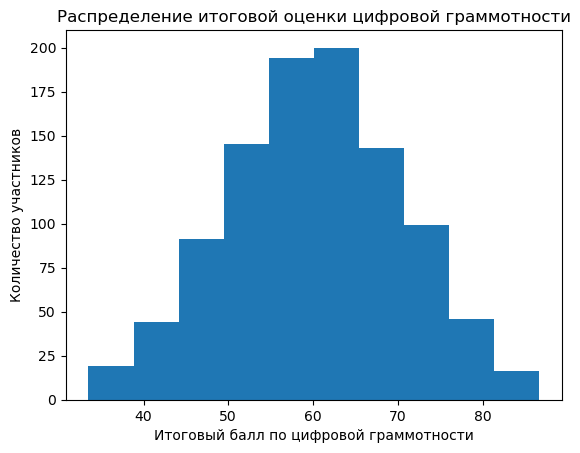

In [28]:
df['Overall_Literacy_Score'].plot(kind = "hist", title='Распределение итоговой оценки цифровой граммотности', 
                                  xlabel='Итоговый балл по цифровой граммотности', ylabel='Количество участников'); 

Гистограмма показывает, что большая часть участников получили итоговый балл в диапазоне от 50 до 70, что близко к среднему значению (60.23). 
Можно сделать вывод, что основная доля участников обладает средним уровнем цифровой грамотности. 

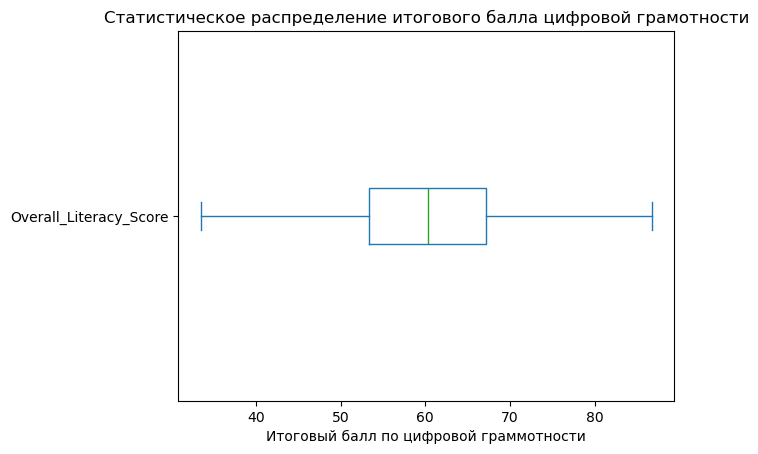

In [30]:
df['Overall_Literacy_Score'].plot(kind = "box", vert = False, title='Статистическое распределение итогового балла цифровой грамотности', xlabel='Итоговый балл по цифровой граммотности'); 

Ящик с усами демонстрирует размах значений от 32.4 до 89.9, а также медианное значение 60.3.
Основная масса участников получила итоговый балл в диапозоне 50-70, но присутствуют выбросы - т.е. какие-то участники написали работы на слишком низкий или высокий балл.


In [42]:
df_2 = df.groupby("Gender")["Overall_Literacy_Score"].mean()
df_2

Gender
Female    60.245356
Male      60.471300
Other     58.592045
Name: Overall_Literacy_Score, dtype: float64

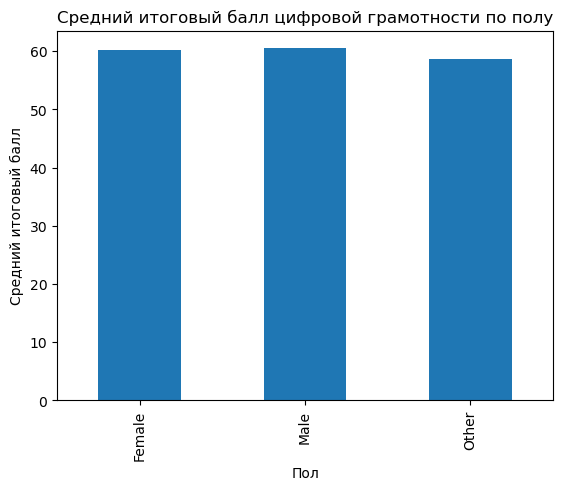

In [48]:
df_2.plot(kind="bar", title='Средний итоговый балл цифровой грамотности по полу', xlabel='Пол', ylabel='Средний итоговый балл'); 

Для лучшего визуального восприятия результатов ограничим ось y

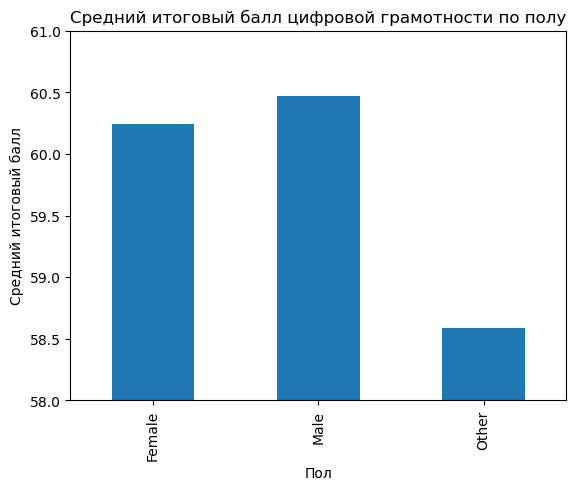

In [44]:
df_2.plot(kind="bar", ylim=(58,61), title='Средний итоговый балл цифровой грамотности по полу', xlabel='Пол', ylabel='Средний итоговый балл'); 

По графику столбчатой диаграммы можно сделать вывод, что результаты мужчин и женщин не имеют сильных различий, а значит пол участника не оказывает сильного влияния на уровень цифровой грамотности. Также среди участников были те, кто выбрал другой пол, эта группа людей имеет более низкий средний результат, но разница менее 2 баллов не является существенной.

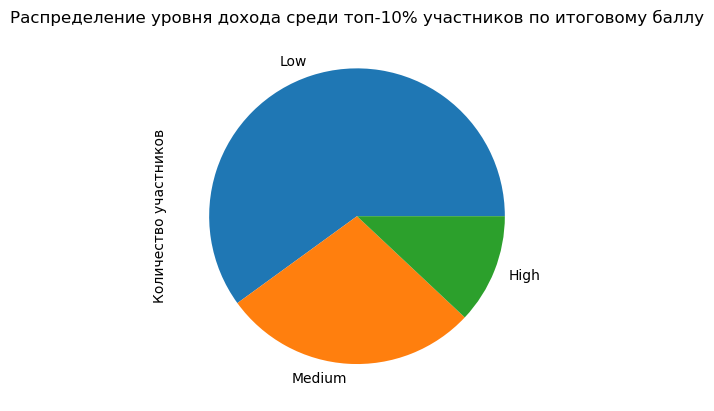

In [39]:
group1 = df['Overall_Literacy_Score'].quantile(0.9)
df_clean = df[(df['Overall_Literacy_Score']>=group1)]
df_clean['Household_Income'].value_counts().plot(kind = 'pie', title='Распределение уровня дохода среди топ-10% участников по итоговому баллу', ylabel='Количество участников');

По графику видно, что больше половины участников с наилучшим баллом (топ 10% от общего) имеют низкий уровень дохода, тогда как учатников с высоким уровнем дохода меньше всего. 

In [42]:
df_3 = df.groupby("Household_Income")["Overall_Literacy_Score"].mean()
df_3

Household_Income
High      60.915574
Low       60.128162
Medium    60.043262
Name: Overall_Literacy_Score, dtype: float64

In [44]:
df_clean2 = pd.concat([df["Age"], df['Basic_Computer_Knowledge_Score'], df ['Internet_Usage_Score'], 
                        df ['Mobile_Literacy_Score'],
                        df['Average_Time_Per_Module'], 
                        df['Quiz_Performance'],
                        df['Session_Count'], 
                        df['Adaptability_Score'], 
                        df['Feedback_Rating'],
                        df['Skill_Application'], 
                        df ['Overall_Literacy_Score']], axis=1)
df_clean2

,Age,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,Average_Time_Per_Module,Quiz_Performance,Session_Count,Adaptability_Score,Feedback_Rating,Skill_Application,Overall_Literacy_Score
0,43,25,1,33,15.85,92,12,77,4,51,58.2
1,60,22,14,35,22.24,88,24,76,4,98,55.3
2,47,14,31,14,12.15,67,17,67,5,75,52.3
3,34,6,32,17,25.59,69,28,59,1,61,55.5
4,50,14,41,19,16.65,76,10,90,4,82,59.3
...,...,...,...,...,...,...,...,...,...,...,...
995,30,18,49,27,28.28,61,20,98,4,85,73.1
996,30,25,24,24,14.06,73,26,74,2,76,60.5
997,31,35,19,36,29.91,65,14,66,1,86,63.8
998,62,39,12,47,28.34,91,21,83,4,73,60.0


In [46]:
df_clean2.corr()

,Age,Basic_Computer_Knowledge_Score,Internet_Usage_Score,Mobile_Literacy_Score,Average_Time_Per_Module,Quiz_Performance,Session_Count,Adaptability_Score,Feedback_Rating,Skill_Application,Overall_Literacy_Score
Age,1.000000,0.025588,0.014571,0.023116,-0.048382,0.007063,0.019014,0.011918,0.010241,-0.014070,0.045530
Basic_Computer_Knowledge_Score,0.025588,1.000000,-0.008119,0.022819,-0.017430,0.023603,-0.018771,-0.009498,0.002691,0.021701,0.587683
Internet_Usage_Score,0.014571,-0.008119,1.000000,0.006484,-0.035797,-0.030235,-0.040513,-0.021456,0.031800,0.008894,0.441917
Mobile_Literacy_Score,0.023116,0.022819,0.006484,1.000000,0.052494,-0.052484,0.016315,0.071619,0.003617,-0.004828,0.463222
Average_Time_Per_Module,-0.048382,-0.017430,-0.035797,0.052494,1.000000,0.010963,-0.063120,-0.023408,0.042530,0.016479,-0.019140
Quiz_Performance,0.007063,0.023603,-0.030235,-0.052484,0.010963,1.000000,0.047192,-0.020486,0.001310,-0.008968,-0.017721
Session_Count,0.019014,-0.018771,-0.040513,0.016315,-0.063120,0.047192,1.000000,0.044470,0.019262,-0.031233,0.006087
Adaptability_Score,0.011918,-0.009498,-0.021456,0.071619,-0.023408,-0.020486,0.044470,1.000000,0.015330,0.033322,0.011777
Feedback_Rating,0.010241,0.002691,0.031800,0.003617,0.042530,0.001310,0.019262,0.015330,1.000000,0.016185,0.038753
Skill_Application,-0.014070,0.021701,0.008894,-0.004828,0.016479,-0.008968,-0.031233,0.033322,0.016185,1.000000,0.018317


Общий уровень цифровой грамотности (Overall Literacy Score) больше всего зависит от базовых знаний компьютера (0.589), уровня использования интернета (0.448) и мобильной грамотности (0.468).(Заметная прямая корреляция) 
Также можно проследить слабую обратную корреляцию между использованием интернета и количеством сессий - чем больше участник пользуется интернетом, тем меньше учебных сессий он совершает. 


# Экономический бонус

### Статьи и обзор литературы:

1) Глухов А.П., Соломина И.Г. Факторы и агенты формирования цифровой грамотности обучающихся // Цифровая гуманитаристика и технологии в образовании (DHTE 2023): сб. статей IV Международной научно-практической конференции. 16–17 ноября 2023 г. | Digital Humanities and Technology in Education (DHTE 2023): Сollection of Articles of the IV International Scientific and Practical Conference. November 16–17, 2023. / Под ред. В.В. Рубцова, М.Г. Сороковой, Н.П. Радчиковой. – Москва : ФГБОУ ВО МГППУ, 2023. С. 641–652.
URL: https://psyjournals.ru/nonserialpublications/dhte2023/contents/Glukhov_Solomina
 (дата обращения 12.02.202)


В статье исследуется, как социальное окружение, образовательные практики и медиапотребление влияют на развитие цифровых навыков. Основное внимание уделяется роли социальной среды, где семья, друзья, учителя и другие значимые фигуры оказывают существенное влияние на процесс освоения цифровых технологий. Образовательные учреждения также рассматриваются как важные агенты формирования цифровой грамотности. В статье подчеркивается значение специализированных курсов, тренингов и модернизации образовательных программ, которые включают в себя использование современных цифровых инструментов. Среди ключевых факторов, влияющих на цифровую грамотность, авторы выделяют уровень доступа к устройствам и интернету, а также социально-экономический статус семьи. Наличие технических ресурсов, таких как компьютеры или планшеты, обеспечивает возможность для обучения, тогда как их недостаток может стать серьезным барьером.

Выводы статьи подтверждают актуальность включения переменных, таких как уровень образования, доход семьи, доступ к интернету и участие в образовательных программах, в ваш анализ.

2. Витольник Галина Адамовна, Витольник Владимир Николаевич ЦИФРОВАЯ ГРАМОТНОСТЬ И ФОРМИРОВАНИЕ ЦИФРОВЫХ КОМПЕТЕНЦИЙ // Проблемы современного педагогического образования. 2023. №80-2. URL: https://cyberleninka.ru/article/n/tsifrovaya-gramotnost-i-formirovanie-tsifrovyh-kompetentsiy (дата обращения: 12.02.2025).

В данной статье рассматривается важность цифровой грамотности как ключевого компонента в рамках современной инновационной экономики. Автор акцентирует внимание на том, как изменение социально-экономических условий и развитие технологий влияют на потребности общества в цифровых навыках. Он также подчеркивает, что цифровая грамотность становится важным фактором конкурентоспособности на рынке труда, влияя на адаптацию людей к новым экономическим реалиям. Кроме того, высокий уровень цифровых навыков способствует устойчивому экономическому росту, особенно в условиях цифровой трансформации.

Статья подтверждает необходимость изучения таких факторов, как образование, занятость и доход, а также их взаимосвязь с формированием цифровых навыков

3. Миронова О. А. Приоритеты цифровой экономики и специфические особенности обучения цифровой грамотности поколения y и z // Ученые записки Санкт-Петербургского имени В. Б. Бобкова филиала Российской таможенной академии. 2018. №4 (68). URL: https://cyberleninka.ru/article/n/prioritety-tsifrovoy-ekonomiki-i-spetsificheskie-osobennosti-obucheniya-tsifrovoy-gramotnosti-pokoleniya-y-i-z (дата обращения: 12.02.2025).

Статья исследует основные направления и вызовы, связанные с развитием цифровой грамотности у молодежи, особенно в контексте цифровой экономики. В статье акцентируется внимание на различиях в восприятии и освоении цифровых технологий поколениями Y и Z, а также на специфических подходах, необходимых для обучения этих групп. Поколение Y (миллениалы) и поколение Z имеют разные характеристики восприятия технологий и разные образовательные потребности. Поколение Y чаще использует технологии в профессиональной деятельности, тогда как поколение Z проявляет высокую адаптивность к цифровым инструментам в повседневной жизни. Статья анализирует, как эти различия влияют на формирование навыков, необходимых для успешной адаптации в цифровой экономике, а также подчеркивает важность учета демографических факторов, таких как возраст и образовательные потребности, в анализе цифровой грамотности.

4. Рассаднев Э. С., Осипенко А. А., Лубянков А. С. ЦИФРОВАЯ ГРАМОТНОСТЬ НАСЕЛЕНИЯ КАК ФАКТОР РАЗВИТИЯ ЦИФРОВОЙ ЭКОНОМИКИ В РОССИИ // Вестник Пермского университета. Серия: Математика. Механика. Информатика. 2021. №1 (52). URL: https://cyberleninka.ru/article/n/tsifrovaya-gramotnost-naseleniya-kak-faktor-razvitiya-tsifrovoy-ekonomiki-v-rossii (дата обращения: 12.02.2025).

Статья исследует роль цифровой грамотности в формировании и развитии цифровой экономики в России. В работе подчеркивается, что успешное развитие цифровой экономики невозможно без повышения уровня цифровой грамотности среди широких слоев населения, поскольку многие современные профессии и сферы деятельности требуют активного использования цифровых технологий. В статье рассматриваются текущие проблемы и вызовы, связанные с недостаточной цифровой грамотностью, а также предлагаются пути их решения через развитие образовательных программ и инициатив по обучению цифровым навыкам.

Автор акцентирует внимание на том, как повышение уровня цифровой грамотности способствует улучшению экономической активности населения, повышению производительности труда и созданию новых рабочих мест в высокотехнологичных отраслях.

### Экономические гипотезы:

**Гипотеза 1:** Уровень образования оказывает положительное влияние на цифровую грамотность.

Согласно литературе (например, приведенная выше статья «Цифровая грамотность населения как фактор развития цифровой экономики в России»), образование является ключевым фактором, способствующим освоению цифровых навыков. Люди с более высоким уровнем образования чаще работают с цифровыми технологиями, имеют доступ к образовательным ресурсам и понимают необходимость цифровой грамотности для трудоустройства.

**Гипотеза 2:** Уровень дохода положительно влияет на цифровую грамотность.

Семьи с более высоким доходом имеют больший доступ к цифровым устройствам, высокоскоростному интернету и образовательным программам. Это делает их более адаптированными к использованию технологий. Таким образом, существует связь между экономическими ресурсами и доступом к цифровым инструментам.

**Гипотеза 3:** Тип местности, ближе к городскому, (semi-rural) способствует более высокому уровню цифровой грамотности, чем сельский (rural).

Люди, живущие в городах, имеют больше возможностей для доступа к современным технологиям, образовательным программам и стабильному интернету. Проблема цифрового неравенства между городским и сельским населением рассматривается в статье “ПРЕОДОЛЕНИЕ ЦИФРОВОГО НЕРАВЕНСТВА СЕЛЬСКИХ ТЕРРИТОРИЙ”

### Переменные для анализа:

**1) Демографические переменные:**

•	Возраст: Указывается в годах. Используется для анализа поколенческих различий в цифровой грамотности. Например, поколения Y и Z (статья о цифровой грамотности молодежи) имеют более высокий уровень навыков, чем старшие поколения.

•	Пол (Gender): Категориальная переменная (Мужчина/Женщина/Другое). Помогает выявить гендерные различия в цифровой грамотности.

•	Тип местности (Location_Type): Категориальная переменная (Полу-сельская/Село). Используется для изучения различий в доступе к цифровым технологиям.

**2) Социально-экономические переменные:**

•	Уровень образования (Education_Level): Категориальная переменная (Среднее, Высшее и т.д.). Измеряет степень формального образования.

•	Доход домохозяйства (Household_Income): Категориальная переменная. Отражает экономические возможности семьи, влияющие на доступ к технологиям.

•	Статус занятости (Employment_Status): Категориальная переменная (Занятый, Безработный, Студент и т.д.). Помогает понять, как трудоустройство влияет на цифровую грамотность.

**3. Переменные цифровой грамотности (до и после обучения):**

•	Базовые знания компьютера (Basic_Computer_Knowledge_Score): Дискретная переменная. Отражает исходный уровень знаний.

•	Навыки использования интернета (Internet_Usage_Score): Дискретная переменная. Оценивает умение использовать интернет для работы или повседневной жизни.

•	Мобильная грамотность (Mobile_Literacy_Score): Дискретная переменная. Показывает умение использовать мобильные устройства.

•	Пост-тренинговые показатели цифровой грамотности (Post_Training_...): Дискретная переменная. Измеряет улучшения после прохождения образовательных модулей.

**4. Образовательные и поведенческие переменные:**

•	Количество завершенных модулей (Modules_Completed): Дискретная переменная (шт.). Используется для оценки вовлеченности в образовательный процесс.

•	Среднее время на модуль (Average_Time_Per_Module): Непрерывная переменная. Указывает на уровень вовлеченности и сложности восприятия.

•	Результаты тестов (Quiz_Performance): Дискретная переменная (баллы). Оценивает успешность освоения материала.

**5. Социально-экономический эффект:**

•	Трудовой эффект (Employment_Impact): Категориальная переменная (Есть/Нет). Показывает, как повышение цифровой грамотности повлияло на трудоустройство.

•	Применение навыков (Skill_Application): Дискретная переменная. Указывает на практическую пользу обучения.

•	Общий уровень грамотности (Overall_Literacy_Score): Непрерывная переменная. Комплексный индекс, агрегирующий основные цифровые показатели.

# КТ3

## Тест на сопряженность (независимость) 𝜒2

Н0: уровень цифровой грамотности не зависит от уровня школьного образования

H1: уровень цифровой грамотности зависит от уровня школьного образования

In [15]:
import pandas as pd
import scipy.stats as stats

# Группировка уровня образования
education_levels = {
    'Primary': 'Primary',
    'Secondary': 'Secondary',
    'High School': 'High School',}
df['Education_Level_Grouped'] = df['Education_Level'].map(education_levels)

# Группировка уровня цифровой грамотности
def categorize_literacy(score):    #Данные для деления на уровни были выбраны нами, исходя из общепринятой градации оценок за разные тесты, предварительно было проверено, что изменения в сторону +-10 баллов качественно не влияют на результат тестирования гипотезы
    if score < 50:
        return 'Низкий'
    elif 50 <= score < 70:
        return 'Средний'
    else:
        return 'Высокий'

df['Literacy_Level'] = df['Overall_Literacy_Score'].apply(categorize_literacy)

# Создание таблицы сопряженности
contingency_table = pd.crosstab(df['Education_Level_Grouped'], df['Literacy_Level'])
contingency_table

Literacy_Level,Высокий,Низкий,Средний
Education_Level_Grouped,,,
High School,46,42,156
Primary,54,40,180
Secondary,48,48,171


In [16]:
from scipy.stats import chi2_contingency
result = chi2_contingency(contingency_table)
result

Chi2ContingencyResult(statistic=1.3183315354650655, pvalue=0.8582577289203696, dof=4, expected_freq=array([[ 46.00254777,  40.40764331, 157.58980892],
       [ 51.65859873,  45.37579618, 176.9656051 ],
       [ 50.3388535 ,  44.21656051, 172.44458599]]))

In [17]:
# Вывод результатов
print(f"Хи-квадрат: {result[0]}")
print(f"p-value: {result[1]}")

if result[1] < 0.05: #возьмем уровень значимости 5%
    print("Отвергаем нулевую гипотезу: уровень школьного образования влияет на уровень цифровой грамотности.")
else:
    print("Не отвергаем нулевую гипотезу: уровень школьного образования не влияет на уровень цифровой грамотности.")

Хи-квадрат: 1.3183315354650655
p-value: 0.8582577289203696
Не отвергаем нулевую гипотезу: уровень школьного образования не влияет на уровень цифровой грамотности.


Вывод: цифровая грамотность может зависеть не только от школьного образования, но и от самообучения, доступа к технологиям, возраста и других факторов. Люди с начальным уровнем школьного образования могут активно пользоваться интернетом. К тому же школьное образование не всегда включает цифровые навыки, особенно если брать во внимание, что в датасете представлены данны по местностям "Rural", "Semi-Rural".

## Двувыборочный t-тест

H0: Средний Mobile_Literacy_Score одинаков у мужчин и женщин

H1: Средний Mobile_Literacy_Score разный у мужчин и женщин

In [29]:
from scipy.stats import ttest_ind

# Разделяем данные по полу
male_literacy = df[df["Gender"] == "Male"]["Mobile_Literacy_Score"].dropna()
female_literacy = df[df["Gender"] == "Female"]["Mobile_Literacy_Score"].dropna()

In [25]:
# Перед тестом необходимо проверить равенство дисперсий двух выборок
print(male_literacy.var())
print(female_literacy.var())

228.73718446112775
221.1107776312959


Значение дисперсий очень близко друг к другу, так что можем проводить двувыборочный т-тест

In [22]:
# Выполняем t-тест
t_stat, p_value = ttest_ind(male_literacy, female_literacy, equal_var=False)

# Выводим результаты
print(t_stat, p_value)

if p_value < 0.05: #возьмем уровень значимости 5%
    print("Отвергаем нулевую гипотезу: средний Mobile_Literacy_Score различается у мужчин и женщин.")
else:
    print("Не отвергаем нулевую гипотезу: нет статистически значимой разницы в Mobile_Literacy_Score у мужчин и женщин.")

0.321648436682911 0.7477933747000264
Не отвергаем нулевую гипотезу: нет статистически значимой разницы в Mobile_Literacy_Score у мужчин и женщин.


Вывод: Тест показал, что нет значимой разницы в среднем уровне Mobile_Literacy_Score между мужчинами и женщинами. Это означает, что гендерный фактор, вероятно, не оказывает значительного влияния на мобильную грамотность в данной выборке. Хотя могут существовать какие-либо стереотипы о гендерных различиях в цифровой грамотности, результаты данного теста их не подтверждают

## Одновыборочный t-тест

В датасете содержатся показатели уровня цифровой грамотности и факторы, которые на него влияют, в том числе уровень использования интернета.

H0: Средний уровень использования интернета равен 30

H1: Средний уровень использования интернета ниже 30

In [67]:
from scipy import stats
result = stats.ttest_1samp(a=df["Internet_Usage_Score"], popmean=30, alternative='less')
print(result)

TtestResult(statistic=-10.933966920751812, pvalue=1.1651381657858834e-26, df=996)


In [69]:
print (result.pvalue > 0.1) #уровень значимости 10% 
print(result.pvalue > 0.05) #уровень значимости 5%
print(result.pvalue > 0.01) #уровень значимости 1%

False
False
False


Вывод: p_value < a , значит Нулевая гипотеза отвергается при любом уровне значимости, средний уровень использования интернета ниже 30. 

# КТ4 #

## Линейная регрессия 

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Выбираем три предиктора и целевую переменную
X = df[["Basic_Computer_Knowledge_Score", "Internet_Usage_Score", "Mobile_Literacy_Score"]]
y = df["Overall_Literacy_Score"]

# Добавляем константу
X = sm.add_constant(X)

# Строим модель
model = sm.OLS(y, X).fit()

# Выводим результаты
print(model.summary())


                              OLS Regression Results                              
Dep. Variable:     Overall_Literacy_Score   R-squared:                       0.745
Model:                                OLS   Adj. R-squared:                  0.744
Method:                     Least Squares   F-statistic:                     965.5
Date:                    Wed, 12 Mar 2025   Prob (F-statistic):          8.87e-294
Time:                            20:52:46   Log-Likelihood:                -3047.7
No. Observations:                     997   AIC:                             6103.
Df Residuals:                         993   BIC:                             6123.
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

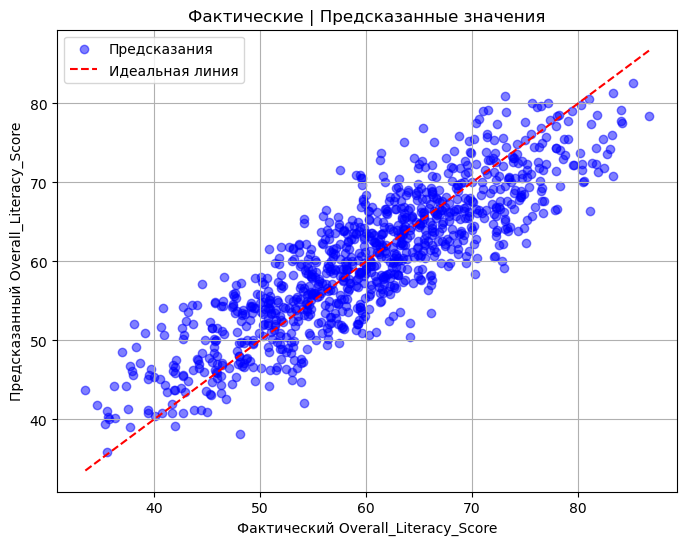

R²: 0.7446877592795902
MSE: 26.465833261178336
MAE: 4.1423538859923985


In [78]:
# Делаем предсказания
y_pred = model.predict(X)

# Вычисляем метрики
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

# Визуализируем фактические и предсказанные значения
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.5, color="blue", label="Предсказания")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "--", color="red", label="Идеальная линия")
plt.xlabel("Фактический Overall_Literacy_Score")
plt.ylabel("Предсказанный Overall_Literacy_Score")
plt.title("Фактические | Предсказанные значения")
plt.legend()
plt.grid()
plt.show()


print(f"R²: {r2:}")
print(f"MSE: {mse:}")
print(f"MAE: {mae:}")

### Выводы 

Что касается оценки качества модели,

Коэффициент детерминации (R²): 0.748
Значит, модель хорошо предсказывает результаты изменчивости целевой переменной (Overall_Literacy_Score), 74.8% объясняется выбранными для построения регрессии признаками
Среднеквадратичная ошибка (MSE): 26.63
В среднем модель ошибается примерно на 26.63 единицы в квадрате. Чем ниже MSE, тем точнее предсказания.
Средняя абсолютная ошибка (MAE): 4.16
Что касается влияние предикторов, то при любом уровне значимости все 3 признака оказываются статистияески значимы, так как p-value для Basic_Computer_Knowledge_Score, Internet_Usage_Score и Mobile_Literacy_Score = 0.000

Анализируя коэффициенты, можно заметить, что наибольший вклад в итоговый балл вносит признак Basic_Computer_Knowledge_Score, что логично, так как компьютерная грамотность значима для цифровой грамотности.

Глядя на визуализацию, можно заметить, что большинство точек лежат близко к красной линии, значит, модель делает хорошие предсказания, но есть небольшие расхождения.

# Эконометрический бонус

### Тест Чоу

Тест Чоу — это статистический тест, который проверяет, отличаются ли параметры линейной регрессии в двух подвыборках. Он помогает определить, стоит ли строить одну общую модель или две отдельные для разных групп данных.

Он сравнивает остаточную сумму квадратов (RSS) полной модели с остаточными суммами квадратов двух отдельных моделей.

H0 = структура коэффициентов одинакова в двух группах

H1 = структура коэффициентов различается в двух группах

In [38]:
# Выбираем предикторы и целевую переменную
X = df[["Basic_Computer_Knowledge_Score", "Internet_Usage_Score", "Mobile_Literacy_Score"]]
y = df["Overall_Literacy_Score"]

# Добавляем константу
X = sm.add_constant(X)

# Строим полную модель
model_full = sm.OLS(y, X).fit()

In [39]:
# Разделяем данные на две подвыборки (например, по медиане Mobile_Literacy_Score)
threshold = df["Mobile_Literacy_Score"].median()
df_low = df[df["Mobile_Literacy_Score"] <= threshold]
df_high = df[df["Mobile_Literacy_Score"] > threshold]

Разделяя данные, мы пытаемся выяснить, меняется ли зависимость между переменными для разных уровней цифровой грамотности. Это поможет проверить, одинаковы ли коэффициенты регрессии для разных групп


In [40]:
# Формируем модели для двух подвыборок
X_low = sm.add_constant(df_low[["Basic_Computer_Knowledge_Score", "Internet_Usage_Score", "Mobile_Literacy_Score"]])
y_low = df_low["Overall_Literacy_Score"]
model_low = sm.OLS(y_low, X_low).fit()

X_high = sm.add_constant(df_high[["Basic_Computer_Knowledge_Score", "Internet_Usage_Score", "Mobile_Literacy_Score"]])
y_high = df_high["Overall_Literacy_Score"]
model_high = sm.OLS(y_high, X_high).fit()

# Вычисляем тест Чоу
SSR_full = sum(model_full.resid**2)
SSR_low = sum(model_low.resid**2)
SSR_high = sum(model_high.resid**2)

n_full = len(df)
n_low = len(df_low)
n_high = len(df_high)
k = X.shape[1] 

# F-статистика теста Чоу
from scipy.stats import f
F_stat = ((SSR_full - (SSR_low + SSR_high)) / k) / ((SSR_low + SSR_high) / (n_full - 2 * k))
p_value = 1 - f.cdf(F_stat, k, n_full - 2 * k)

print(f"F-статистика: {F_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Отвергаем нулевую гипотезу — структура коэффициентов различается в двух группах.")
else:
    print("Не отвергаем нулевую гипотезу — структура коэффициентов одинакова в двух группах.")

F-статистика: 2.384648094789716
P-value: 0.049696445096283126
Отвергаем нулевую гипотезу — структура коэффициентов различается в двух группах.


**Выводы:** Мы можем сделать вывод, что параметры модели не одинаковы для двух подгрупп (по уровню мобильной грамотности). Это говорит о том, что в зависимости от уровня мобильной грамотности необходимо учитывать разные зависимости между предикторами и целевой переменной.
Например, для людей с низким уровнем мобильной грамотности (группа с низкими значениями Mobile_Literacy_Score), базовые знания компьютера могут иметь более сильное влияние на общий уровень цифровой грамотности, в то время как для людей с высоким уровнем мобильной грамотности (группа с высокими значениями Mobile_Literacy_Score) влияние этих факторов может быть менее выражено.

### Методологические проблемы

**1) Проблема мультиколлинеарности**

Мультиколлинеарность возникает, когда несколько предикторов сильно коррелируют друг с другом. Это может затруднить оценку индивидуального вклада каждого предиктора.

Можно вычислить коэффициент корреляции между предикторами и проверить, нет ли сильной корреляции. Если она присутствует, возможно, стоит исключить один из коррелирующих признаков

**2. Нормальность ошибок**

Линейная регрессия предполагает, что ошибки следуют нормальному распределению. Если это условие нарушено, то результаты регрессии могут быть ненадежными.

Если ошибки не нормальны, можно попытаться применить трансформацию зависимой переменной или использовать непараметрические методы.


**3. Гетероскедастичность:**

Гетероскедастичность происходит, когда дисперсия ошибок зависит от значений предикторов, что нарушает предположение о постоянной дисперсии ошибок в линейной регрессии.

Можно применить преобразования к зависимой переменной, такие как логарифмирование, чтобы стабилизировать дисперсию ошибок

# Бонус ML

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


df = pd.read_csv('digital_literacy_dataset .csv')

# Выбираем  предикторы и целевую переменную
X = df[["Basic_Computer_Knowledge_Score", "Internet_Usage_Score", "Mobile_Literacy_Score"]]
y = df["Overall_Literacy_Score"]

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем модель случайного леса
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Делаем прогнозы
y_pred_rf = rf_model.predict(X_test)

# Оцениваем модель
print("R²:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R²: 0.6772365817694588
MSE: 31.31256953000003
MAE: 4.563309999999998


## Выводы 

**Оценка качества модели по трем показателям и сравнение с показателями линейной регрессии:**

R²: У линейной регрессии показатель R² (0.7446877592795902) выше, чем у случайного леса (0.6772365817694588). Это говорит о том, что линейная регрессия в данном случае объясняет вариацию целевой переменной на 74.47%, в то время как случайный лес объясняет вариацию только на 67.72%. Линейная регрессия, в данном случае, лучше подходит для этого датасета.

MAE: Линейная регрессия имеет меньшую среднюю абсолютную ошибку (4.1423538859923985) по сравнению с случайным лесом (4.563309999999998). Это означает, что предсказания линейной регрессии в среднем ближе к реальным значениям, чем предсказания случайного леса.

MSE: Линейная регрессия также имеет меньшую среднеквадратическую ошибку (26.465833261178336), чем случайный лес (31.31256953000003). Это подтверждает, что линейная модель более точна в предсказаниях

**Преимущества нелинейных моделей по сравнению с линейными:**
1. Линейные модели могут строиться только на данных, имеющих линейные зависимости, в то время как нелинейные модели могут быть использованы на более сложных данных.
2. Случайный лес и другие нелинейные модели могут быть менее чувствительны к выбросам, так как они строят модель, основываясь на сегментах данных, а не на всей выборке сразу. Линейные модели могут значительно искажаться из-за выбросов.
3. Нелинейные модели могут автоматически выделять важные признаки и учитывать их сложные взаимодействия. В случае линейной регрессии, нужно вручную выбирать признаки, учитывая наличие линейной зависимости. 